In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import albumenations as A
import albumenations.pytorch import ToTensorV2

import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from tqdm import tqdm

Helper Functions

In [ ]:
#iou calculation function
def iou(box1, box2, is_pred=True):
  if is_pred:
    b1_x1 = box1[..., 0:1] - box[..., 2:3] /2
    b1_y1 = box1[..., 1:2] - box[..., 3:4] /2
    b1_x2 = box1[..., 0:1] - box[..., 2:3] /2
    b1_y2 = box1[..., 1:2] - box[..., 3:4] /2

    b2_x1 = box1[..., 0:1] - box[..., 2:3] /2
    b2_y1 = box1[..., 1:2] - box[..., 3:4] /2
    b2_x2 = box1[..., 0:1] - box[..., 2:3] /2
    b2_y2 = box1[..., 1:2] - box[..., 3:4] /2

    x1 = torch.max(b1_x1, b2_x1)
    y1 = torch.max(b1_y1, b2_y1)
    x2 = torch.max(b1_x2, b2_x2)
    y2 = torch.max(b1_x2, b2_x2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    box1_area = abs((b1_x2 - b1_x1) * (b1_y2 - b1_y1))
    box1_area = abs((b2_x2 - b2_x1) * (b2_y2 - b2_y1))
    union = box1_area + box2_area - intersection

    epsilon = 1e-6
    iou_score = intersection / (union + epsilon)

    return iou_score
  else:
    intersection_area = torch.min(box1[..., 0], box[..., 0] * \
                                  torch.min(box1[...,1], box2[..., 1]))

    box1_area = box1[..., 0] * box1[..., 1]
    box2_area = box2[..., 0] * box2[..., 1]
    union_area = box1_area + box2_area - intersection_area

    iou_score = intersection_area / union_area

    return iou_score

In [ ]:
# NMS: Non maximum suppression to remove overlapping boundary boxes
def nms(bboxes, iou_threshold, threshold):
  bboxes = [box for box in bboxes if box[1] > threshold]

  bboxes = sorted(bboxes, key = lamda x: x[1], reverse = True)

  bboxes_nms = []

  while bboxes:
    first_box = bboxes.pop(0)
    for box in bboxes:
      if box[0] != first_box[0] or iou(
          torch.tensor(first_box[2:]),
          torch.tensor(box[2:]),
      ) < iou_threshold:
      if box not in bboxes_nms:
        bboxes_nms.append(box)

  return bboxes_nms

In [ ]:
#cells to bounding_boxes
def convert_cells_to_bboxes(prediction, anchors, s, is_predictions = True):
  batch_size = predictions.shape[0]
  nms_anchors = len(anchors)
  box_predictions = predictions[..., 1:5]

  if is_predictions:
    anchors = anchors.reshape(1, len(anchors), 1, 1, 2)
    box_predictions[..., 0:2] = torch.sigmoid(box_predictions[..., 0:2])
    box_predictions[..., 2:] = torch.exp(
        box_predictions[..., 2:]) * anchors
    scores = torch.sigmoid(predictions[..., 0:1])
    best_class = torch.argmax(predictions[..., 5:], dim = -1).unsqeeze(-1)

  else:
    scores = predictions[..., 0:1]
    best_class = predictions[..., 5:6]

  cell_indices = (
      torch.arange(s)
      .repeat(predicitions.shape[0], 3, 5, 1)
      .unsqueeze(-1)
      .to(predicions.device)
  )

  x = 1/5 * (box_predictions[..., 0:1] = cell_indices)
  y = 1/5 * (box_predictions[..., 1:2] +
             cell_indices.permute(0,1,3,2,4))
  width_height = 1 / s * box_predictions[..., 2:4]

  converted_bboxes = torch.cat(
      (best_class, scores, x, y, width_height), dim = -1
  ).reshape(batch_size, num_anchors * s * s, 6)

  return converted_bboxes.tolist()

In [ ]:
#plot images with bounding boxes and class labels
def plot_image(image, boxes):
  colour_map = plt.get_cmp("tab20b")
  colors = [colour_map(i) for i in np.linspace(0, 1, len(class_labels))]

  img = np.array(image)
  h, w, _ = img.shape
  fig, ax = plt.subplots(1)

  ax.imshow(img)

  for box in boxes:
    class_pred = box[0]
    box = box[2:]
    upper_left_x = box[0] - box[2] / 2
    upper_left_y = box[1] - box[3] / 2

    rect = patches.Rectangle(
        (upper_left_x * w, upper_left_y *h),
        box[2] * w,
        box[3] * h,
        linewidth = 2,
        edgecolor = colors[int(class_pred)],
        facecolor = "none",
    )

    ax.add_patch(rect)

    plt.text(
        upper_left_x * w,
        upper_left_y * h,
        s = class_labels[int(class_pred)],
        color = "white",
        verticalalignment = "top",
        bbox = {"color": colors[int(class_pred)], "pad": 0},
    )
    plt.show()

In [ ]:
#save checkpoint
def save_checkpoint(model, optimizer, filename = "my_checkpoint.pth.tar"):
  print("==> Saving Checkpoint")
  checkpoint = {
      "state_dict": model.state_dict(),
      "optimizer": optimizer.state_dict(),
  }
  torch.save(checkpoint, filename)

In [ ]:
#load checkpoint
def load_checkpoint(checkpoint_file, model, optimizer, lr):
  print("==> Loading Checkpoint")
  checkpoint = torch.load(checkpoint_file, map_location=device)
  model.load_state_dict(checkpoint["state_dict"])
  optimizer.load_state_dict(checkpoint["optimizer"])

  for param_group in optimizer.param_groups:
    param_group["lr"] = lr

constants

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

load_model = False
save_model = True

checkpoint_file = "checkpoint.pth.tar"

ANCHORS = [
    [(0.28, 0.22), (0.38, 0.48), (0.9, 0.78)],
    [(0.07, 0.15), (0.15, 0.11), (0.14, 0.29)],
    [(0.02, 0.03), (0.04, 0.07), (0.08, 0.06)],
]

batch_size = 32

learning_rate = 1e-5

epochs = 20

image_size = 416

s = [image_size // 32, image_size //16, image_size // 8]

# Class labels
class_labels = [
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat",
    "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

Dataset

In [ ]:
class Dataset(torch.utils.data.Dataset):
  def __init__(
      self, csv_file, image_dir, label_dir, anchors,
      image_size = 416, grid_sizes = [13, 26, 52],
      num_classes = 20, transform = None
  ):

    self.label_list = pd.read_csv(csv_file)
    self.image_dir = image_dir
    self.label_dir = label_dir

    self.image_size = image_size
    self.transform = transform
    self.grid_sizes = grid_sizes

    self.anchors = torch.tensor(
        anchors[0] + anchors[1] + anchors[2])
    self.num_anchors = self.anchors.shape[0]
    self.num_anchors_per_scale = self.num_anchors // 3
    self.num_classes = num_classes
    self.ignore_iou_thresh = 0.5

  def __len__(self):
    return len(self.label_list)

  def __getitem__(self, idx):
    label_path = os.path.join(self.label_dir, self.label_list.iloc[idx, 1])
    bboxes = np.roll(np.loadtxt(fname = label_path, delimiter = " ", ndmin = 2), 4, axis = 1).tolist()

    img_path = os.path.join(self.image_dir, self.label_list.iloc[idx, 0])
    image = np.array(Image.open(img_path).convert("RGB"))

    if self.transform:
      augs = self.transform(image = image, bboxes = bboxes)
      image = augs["image"]
      bboxes = augs["bboxes"]

    targets = [torch.zeros((self.num_anchors_per_scale, s, s, 6))
                for s in self.grid_sizes]
    for box in bboxes:
      iou_anchors = iou(torch.tensor(box[2:4]),
                        self.anchors,
                        is_pred=False)
      anchor_indices = iou_anchors.argsort(desceneding=True, dim = 0)
      x,y,width,height,class_label = box

      has_anchor = [False] * 3
      for anchor_idx in anchor_indices:
        scale_idx = anchor_idx // self.num_anchors_per_scale
        anchor_on_scale = anchor_idx % self.num_anchors_per_scale

        s = self.grid_sizes[scale_idx]

        i,j = int(s*y), int(s*x)
        anchor_taken = targets[scale_idx][anchor_on_scale, i, j, 0]

        if not anchor_taken and not has_anchor[scale_idx]:
          targets[scale_idx][anchor_on_scale, i, j, 0] = 1
          x_cell, y_cell = s*x - j, s*y - i

          width_cell, height_cell = (width * s, height * s)

          box_coordinates = torch.tensor(
              [x_cell, y_cell, width_cell, height_cell]
          )
          targets[scale_idx][anchor_on_scale, i, j, 1:5] = box_coordinates
          targets[scale_idx][anchor_on_scale, i, j, 5] = int(class_label)
          has_anchor[scale_idx] = True

        elif not anchor_taken and iou_anchors[anchor_idx] > self.ignore_iou_thresh:
          targets[scale_idx][anchor_on_scale, i, j, 0] = -1

      return image, tuple(targets)


dataTransformation

In [ ]:
train_transform = A.Compose(
    [
        A.LongestMaxSize(max_size = image_size),
        A.PadIfNeeded(
            min_height = image_size, min_width = image_size, border_mode = cv2.BORDER_CONSTANT
        ),
        A.ColorJitter(
            brightness = 0.5, contrast = 0.5,
            saturation = 0.5, hue = 0.5, p = 0.5
        ),
        A.HorizontalFlis(p=0.5),
        A.Normalize(
            mean=[0,0,0], std = [1, 1, 1], max_pixel_value = 255
        ),
        ToTensorV2()
    ]
    bbox_params = A.BboxParams(
        format = "yolo",
        min_visibility = 0.4,
        label_fields = []
    )
)

test_tranform = A.Compose(
    [
        A.LongestMaxSize(max_size = image_size),
        A.PadIfNeeded(
            min_height = image_size, min_width = image_size, border_mode = cv2.BORDER_CONSTANT
        ),
        A.Normalize(
            mean = [0, 0, 0], std = [1, 1, 1], max_pixel_value = 255
        ),
        ToTensorV2()
    ],
    bbox_params = A.BboxParams(
        format = "yolo",
        min_visibility = 0.4,
        label_fields = []
    )
)

load the dataset

In [ ]:
dataset = Dataset(
    csv_file = "train.csv",
    image_dir = "image/",
    label_dir = "labels/",
    grid_sizes = [13, 26, 52],
    anchors = ANCHORS,
    transform = test_transform
)

loader = torch.utils.data.DataLoaded(
    dataset = dataset,
    batch_size = 1,
    shuffle = True,
)

GRID_SIZE = [13, 26, 52]
scaled_anchors = torch.tensor(ANCHORS) / (
    1 / torch.tensor(GRID_SIZE).unsqueeze(1).unsqueeze(1).repeat(1,3,2)
)
x,y = next(iter(loader))

boxes = []
for i in range(y[0].shape[1]):
  anchor = scaled_anchors[i]
  boxes += convert_cells_to_bboxes(
      y[i], is_prediction=False, s=y[i].shape[2], anchors = anchor
  )[0]

boxes = nms(boxes, iou_threshold = 1, threshold = 0.7)
plot_image(x[0].permute(1,2,0).to("cpu"),boxes)

Architecture

involves a lot of convolutions and residual blocks

In [ ]:
# CNN block

class CNNBlock(nn.Module):
  def __init__(self, in_channels, out_channels, use_batch_norm = True, **kwargs):
    super().__init__()
    self.conv = nn.Conv2d(in_channels, out_channels, bias = not use_batch_norm, **kwards)
    self.bn = nn.BatchNorm2d(out_channels)
    self.activation = nn.LeakyReLU(0.1)
    self.use_batch_norm = use_batch_norm

  def forward(self, x):
    # apply the convolution
    x = self.conv(x)
    # apply batch norm as needed
    if self.use_batch_norm:
      x = self.bn(x)
      return self.use_batch_norm:
    else:
      return x

In [ ]:
# residual block
class ResidualBlock(nn.Module):
  def __init__(self, channels, use_residual = True, num_repeats = 1):
    super().init()

    res_layers = []
    for _ in range(num_repeats):
      res_layers += [
          nn.sequential(
              nn.Conv2d(channels, channels // 2, kernel_size = 1),
              nn.BatchNorm2d(channels // 2)
              nn.LeakyReLU(0,1)
              nn.Conv2d(channels //2 , channels, kernel_size = 3, padding = 1),
              nn.BatchNorm2d(channels),
              nn.LeakyReLU(0.1)
          )
      ]
      self.layers = nn.ModuleList(res_layers)
      self.use_residual = use_residual
      self.num_repeats = num_repeats

    #forward pass
    def forward(self, x):
      for layer in self.layers:
        residual = x
        x = layer(x)
        if self.use_residual:
          x = x + residual
        return x

In [ ]:
#scale prediction block
class ScalePrediction(nn.Module):
  def __init__(self, in_channels, num_classes):
    super().__init__()

    self.pred = nn.Sequential(
        nn.Conv2d(in_channels, 2*in_channels, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(2*in_channels),
        nn.LeakyReLU(0.1),
        nn.Conv2d(2*in_channels, (num_classes + 5) * 3, kernel_size = 1),
    )

    def forward(self, x):
      output = self.pred(x)
      output = output.view(x.size(0), 3, self.num_classes + 5, x.size(2), x.size(3))
      output = output.permute(0,1,3,4,2)
      return output

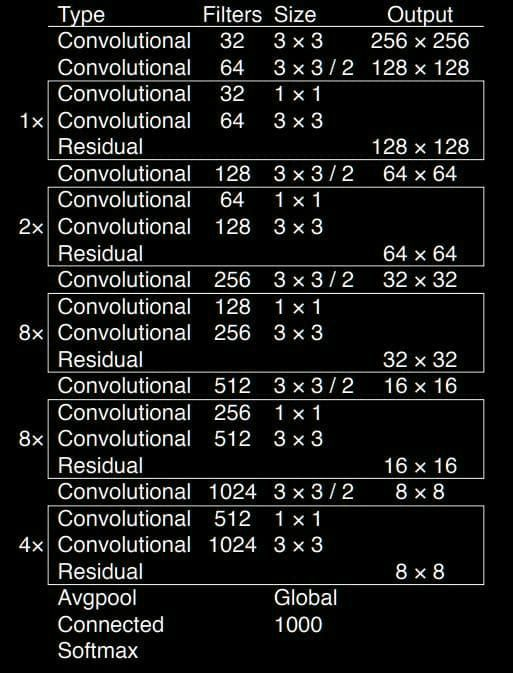

YOLO V3 Model

In [ ]:
class YOLOv3(nn.Module):
  def __init__(self, in_channels = 3, num_classes = 20):
    super().__init__()
    self.num_classes = num_classes
    self.in_channels = in_channels

    #layer list
    self.layers = nn.ModuleList([
        CNNBlock(in_channels, 32, kernel_size = 3, stride = 1, padding = 1),
        CNNBlock(32, 64, kernel_size = 3, stride = 2, padding = 1),
        ResidualBlock(64, num_repeats = 1),
        CNNBlock(64, 128, kernel_size = 3, stride = 2, padding = 1),
        ResidualBlock(128, num_repeats = 2),
        CNNBlock(128, 256, kernel_size = 3, stride = 2, padding = 1),
        ResidualBlock(256, num_repeats = 8),
        CNNBlock(256, 512, kernel_size = 3, stride = 2, padding = 1),
        ResidualBlock(512, num_repeats = 8),
        CNNBlock(512, 1024, kernel_size = 3, stride = 2, padding = 1),
        ResidualBlock(1024, num_repeats = 4),
#---------
        CNNBlock(1024, 512, kernel_size = 1, stride = 1, padding = 0),
        CNNBlock(512, 1024, kernel_size = 3, stride = 1, padding = 1),
        ResidualBlock(1024, use_residual = False, num_repeats = 1),

        CNNBlock(1024, 512, kernel_size = 1, stride = 1, padding = 0),
        ScalePrediction(512, num_classes = num_classes),
        CNNBlock(512, 256, kernel_size = 1, stride = 1, padding = 0),
        nn.Upsample(scale_factor = 2),
#---------
        CNNBlock(768, 256, kernel_size = 1, stride = 1, padding = 0),
        CNNBlock(256, 512, kernel_size = 3, stride = 1, padding = 1),
        ResidualBlock(512, use_residual = False, num_repeats = 1),

        CNNBlock(512, 256, kernel_size = 1, stride = 1, padding = 0),
        ScalePrediction(256, num_classes = num_classes),
        CNNBlock(256, 128, kernel_size = 1, stride = 1, padding = 0),
        nn.Upsample(scale_factor = 2),
#----------
        CNNBlock(384, 128, kernel_size = 1, stride = 1, padding = 0),
        CNNBlock(128, 256, kernel_size = 3, stride = 1, padding = 1),
        ResidualBlock(256, use_residual = False, num_repeats = 1),
        CNNBlock(256, 128, kernel_size = 1, stride = 1, padding = 0),
        ScalePrediction(128, num_classes = num_classes)
    ])

  #yolo forward pass with route connections and scale predictions
  def forward(self, x):
    outputs = []
    route_connections = []

    for layer in self.layers:
      if isinstance(layer, ScalePrediction):
        outputs.append(layer(x))
        continue
      x = layer(x)

      if isinstance(layer, ResidualBlock) and layer.num_repeats == 8:
        route_connections.append(x)

      elif isinstance(layer, nn.Upsample):
        x = torch.cat([x, route_connections[-1]], dim = 1)
        route_connections.pop()
    return outputs

test the model

In [ ]:
if __name__ == "__main__":
  num_classes = 20
  IMAGE_SIZE = 416

  model = YOLOv3(num_classes = num_classes)
  x = torch.randn((1, 3, IMAGE_SIZE, IMAGE_SIZE))
  out = model(x)
  print(out[0].shape)
  print(out[1].shape)
  print(out[2].shape)

  assert model(x)[0].shape == (1, 3, IMAGE_SIZE//32, num_classes + 5)
  assert model(x)[1].shape == (1, 3, IMAGE_SIZE//16, num_classes + 5)
  assert model(x)[2].shape == (1, 3, IMAGE_SIZE//8, num_classes + 5)
  print("output shapes are correct!")

Train the model

loss func
L(x,y,w,h,c,p,pc,tc,tx,ty,tw,th)=λcoord​∗Lcoord​+λobj​∗Lobj​+λnoobj​∗Lnoobj​+λclass​∗Lclass​

where,

    λcoord, λobj, λnoobj, and λclass are constants that weight the different components of the loss function (they are set to 1 in the paper).
    Lcoord penalizes the errors in the bounding box coordinates.
    Lobj penalizes the confidence predictions for object detection.
    Lnoobj penalizes the confidence predictions for background regions.
    Lclass penalizes the errors in the class predictions.

In [ ]:
# loss func
class YOLOLoss(nn.Module):
  def __init__(self):
    super().__init__()
    self.mse = nn.MSELoss()
    self.bce = nn.BCEWithLogitsLoss()
    self.cross_entropy = nn.CrossEntropyLoss()
    self.sigmoid = nn.Sigmoid()

  def forward(self, pred, target, anchors):
    obj = target[..., 0] == 1
    no_obj = target[..., 0] == 0

    no_object_loss = self.bce(
        (pred[..., 0:1][no_obj]), (target[..., 0:1][no_obj]),
    )

    anchors = anchors.reshape(1,3,1,1,2)
    box_preds = torch.cat([self.sigmoid(pred[..., 1:3]),
                           torch.exp([pred[..., 3:5]]) * anchors
                           ], dim = -1)
    #intersection over union
    ious = iou(box_preds[obj], target[..., 1:5][obj]).detach()
    object_loss = self.mse(self.sigmoid(pred[..., 0:1][obj]),
                           ious * target[..., 0:1][obj])

    pred[..., 1:3] = self.sigmoid(pred[..., 3:5] / anchors)
    target[..., 3:5] = torch.log(1e-6 + target[..., 3:5] / anchors)
    box_loss = self.mse(pred[..., 1:5][obj],
                        target[..., 1:5][obj])

    class_loss = self.cross_entropy((pred[..., 5:][obj]),
                                    target[..., 5][obbj].long())

    return (
        box_loss
        + object_loss
        + no_object_loss
        + class_loss
    )

Training loop

In [ ]:
def training_loop(loaded, model, optimizer, loss_fn, scalar, scaled_anchors):
  progress_bar = tqdm(loader, leave = True)

  losses = []

  for _, (x, y) in enumerate(progress_bar):
    x = x.to(device)
    y0, y1, y2 = (
        y[0].to(device),
        y[1].to(device),
        y[2].to(device),
    )

    with torch.cuda.amp.autocast():
      outputs = model(x)
      loss = (
          loss_fn(outputs[0], y0, scaled_anchors[0])
        + loss_fn(outputs[1], y1, scaled_anchors[1])
        + loss_fn(outputs[2], y2, scaled_anchors[2])
      )

      losses.append(loss.item())

      optimizer.zero_grad()

      scaler.scale(losss).backward()

      scaler.step(optimizer)

      scaler.update()

      mean_loss = sum(losses) / len(losses)
      progress_bar.set_postfix(loss = mean_loss)

train the model

In [ ]:
model = YOLOv3.to(device)

optimizer = optim.Adam(model.parameters(), lr = learning_rate)

loss_fn = YOLOLoss()

scaler = torch.cuda.amp.GradScaler()

train_dataset = Dataset(
    csv_file = "./data/train.csv",
    image_dir = "./data/images/"
    label_dir = "./data/label/"
    anchors = ANCHORS,
    transform = train_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = batch_size,
    num_workers = 2,
    shuffle = True,
    pin_memory = True,
)

scaled_anchors = (
    torch.tensor(ANCHORE) *
    torch.tensor(s).unsqueeze(1).unsqueeze(1).repeat(1,3,2)
).to(device)

#training the model
for e in range(1, epochs+1):
  print("Epoch:", e)
  training_loop(train_loader, model, optimizer, loss_fn, scaler, scaled_anchors)

  if save_model:
    save_checkpoint(model, optimizer, filename = f"checkpoint.pth.tar")

testing the model

In [ ]:
load_model = true

model = YOLOv3().to(device)
optimizer = optim.Adam(model.parameter(), lr = learning_rate)
loss_fn = YOLOLos()
scaler = torch.cuda.amp.GradScaler()

if load_model:
  load_checkpoint(checkpoint_file, model, optimizer, learning_rate)

test_dataset = Dataset(
    csv_file = "/data/test.csv"
    image_dir = "/data/image/"
    label_dir = "/data/labels/"
    anchors = ANCHORS,
    transform = test_transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = 1,
    num_workers = 2,
    shuffle = True,
)

x,y = next(iter(test_loader))
x = x.to(device)

model.eval()
with torch.no_grad():
  output = model(x)
  bboxes = [[] for _ in range(x.shape[0])]
  anchors = (
      torch.tensor(ANCHORS)
        * torch.tensor(s).unsqueeze(1).unsqueeze(1).repeat(1,3,2)
            ).to(device)

  for i in range(3):
    batch_size, A, S, _, _= output[i].shape
    anchor = anchors[i]
    boxes_scale_i = convert_cells_to_bboxes(
        output[i], anchor, s=S, is_predictions = True
    )
    for idx, (box) in enumerate(boxes_scale_i):
      bboxes[idx] += box
model.train()

for i in range(batch_size):
  nms_boxes = nms(bboxes[i], iou_threshold=0.5, threshold=0.6)
  plot_image(x[i].permute(1,2,0).detach().cpu(), nms_boxes)